In [3]:
pip install notebook jupyterlab

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
pip install tensorflow scikit-learn imbalanced-learn pandas numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import numpy as np
import tensorflow as tf

from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Conv1D, MaxPooling1D, Flatten, LSTM
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# ===================== DATASET PATHS =====================
TRAIN_PATH = r"datasets\UNSW_NB15_training-set.csv"
TEST_PATH  = r"datasets\UNSW_NB15_testing-set.csv"

# ===================== LOAD DATA =====================
train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

# ===================== DROP NON-USEFUL COLUMNS =====================
drop_cols = ['id', 'attack_cat']
train_df.drop(columns=drop_cols, inplace=True, errors='ignore')
test_df.drop(columns=drop_cols, inplace=True, errors='ignore')

# ===================== CATEGORICAL ENCODING =====================
categorical_cols = train_df.select_dtypes(include=['object']).columns

encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

train_df[categorical_cols] = encoder.fit_transform(train_df[categorical_cols])
test_df[categorical_cols]  = encoder.transform(test_df[categorical_cols])

# ===================== SPLIT FEATURES & TARGET =====================
X_train = train_df.drop('label', axis=1)
y_train = train_df['label']

X_test = test_df.drop('label', axis=1)
y_test = test_df['label']

# ===================== FEATURE SCALING =====================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# ===================== HANDLE CLASS IMBALANCE =====================
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# ===================== TARGET PREPARATION =====================
num_classes = 2  # Normal / Attack
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat  = to_categorical(y_test, num_classes)

class_names = ['Normal', 'Attack']

# ===================== ANN MODEL =====================
ann = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

ann.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nTraining ANN...")
ann.fit(
    X_train, y_train_cat,
    epochs=30,
    batch_size=256,
    validation_split=0.2,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=1
)

ann_pred = np.argmax(ann.predict(X_test), axis=1)
print("\nANN Accuracy:", accuracy_score(y_test, ann_pred))
print(classification_report(y_test, ann_pred, target_names=class_names))

# ===================== CNN MODEL =====================
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

cnn = Sequential([
    Conv1D(64, 3, activation='relu', input_shape=(X_train.shape[1], 1)),
    MaxPooling1D(2),
    BatchNormalization(),

    Conv1D(128, 3, activation='relu'),
    MaxPooling1D(2),
    BatchNormalization(),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(num_classes, activation='softmax')
])

cnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nTraining CNN...")
cnn.fit(
    X_train_cnn, y_train_cat,
    epochs=30,
    batch_size=256,
    validation_split=0.2,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=1
)

cnn_pred = np.argmax(cnn.predict(X_test_cnn), axis=1)
print("\nCNN Accuracy:", accuracy_score(y_test, cnn_pred))
print(classification_report(y_test, cnn_pred, target_names=class_names))

# ===================== LSTM MODEL =====================
X_train_lstm = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_lstm  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

lstm = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.3),

    LSTM(64),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

lstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nTraining LSTM...")
lstm.fit(
    X_train_lstm, y_train_cat,
    epochs=30,
    batch_size=256,
    validation_split=0.2,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=1
)

lstm_pred = np.argmax(lstm.predict(X_test_lstm), axis=1)
print("\nLSTM Accuracy:", accuracy_score(y_test, lstm_pred))
print(classification_report(y_test, lstm_pred, target_names=class_names))


c:\Minor\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
c:\Minor\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training ANN...
Epoch 1/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.8888 - loss: 0.2350 - val_accuracy: 0.7282 - val_loss: 0.5206
Epoch 2/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9253 - loss: 0.1581 - val_accuracy: 0.8128 - val_loss: 0.3957
Epoch 3/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9434 - loss: 0.1287 - val_accuracy: 0.9570 - val_loss: 0.1873
Epoch 4/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9495 - loss: 0.1169 - val_accuracy: 0.9220 - val_loss: 0.2585
Epoch 5/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9539 - loss: 0.1097 - val_accuracy: 0.9155 - val_loss: 0.2386
Epoch 6/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9557 - loss: 0.1062 - val_accuracy: 0.9226 - val_loss: 0.2472
Epoch 7/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9575 - loss: 0.1017 - val_accuracy: 0.9058 - val_loss: 0.2502
Epoch 8/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9593 - loss: 0.0973 

c:\Minor\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


284/284 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - accuracy: 0.9362 - loss: 0.1591 - val_accuracy: 0.0524 - val_loss: 2.8093
Epoch 2/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.9587 - loss: 0.1021 - val_accuracy: 0.8333 - val_loss: 0.3966
Epoch 3/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.9615 - loss: 0.0950 - val_accuracy: 0.8885 - val_loss: 0.2801
Epoch 4/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.9638 - loss: 0.0888 - val_accuracy: 0.8766 - val_loss: 0.3335
Epoch 5/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.9651 - loss: 0.0854 - val_accuracy: 0.9141 - val_loss: 0.2316
Epoch 6/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.9662 - loss: 0.0838 - val_accuracy: 0.8898 - val_loss: 0.2850
Epoch 7/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.9668 - loss: 0.0819 - val_accuracy: 0.8537 - val_loss: 0.3916
Epoch 8/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.9672 - loss: 0.0808 - val_accurac

c:\Minor\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


284/284 ━━━━━━━━━━━━━━━━━━━━ 79s 258ms/step - accuracy: 0.8166 - loss: 0.3575 - val_accuracy: 0.5701 - val_loss: 0.7388
Epoch 2/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 70s 248ms/step - accuracy: 0.8843 - loss: 0.2506 - val_accuracy: 0.6426 - val_loss: 0.6346
Epoch 3/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 63s 223ms/step - accuracy: 0.8972 - loss: 0.2179 - val_accuracy: 0.6482 - val_loss: 0.6666
Epoch 4/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 66s 232ms/step - accuracy: 0.9064 - loss: 0.2004 - val_accuracy: 0.5429 - val_loss: 0.7145
Epoch 5/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 88s 311ms/step - accuracy: 0.9154 - loss: 0.1832 - val_accuracy: 0.7584 - val_loss: 0.4955
Epoch 6/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 120s 234ms/step - accuracy: 0.9226 - loss: 0.1673 - val_accuracy: 0.7800 - val_loss: 0.4222
Epoch 7/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 66s 234ms/step - accuracy: 0.9298 - loss: 0.1529 - val_accuracy: 0.8360 - val_loss: 0.3810
Epoch 8/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 67s 235ms/step - accuracy: 0.9339 - loss: 0.1467 - va

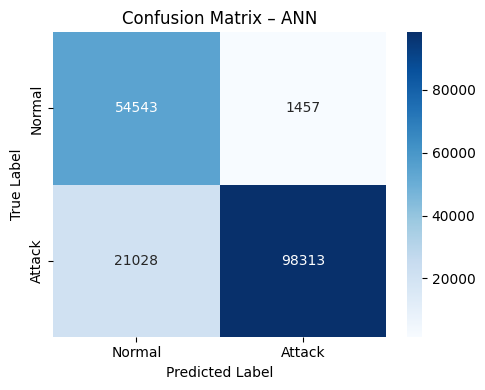

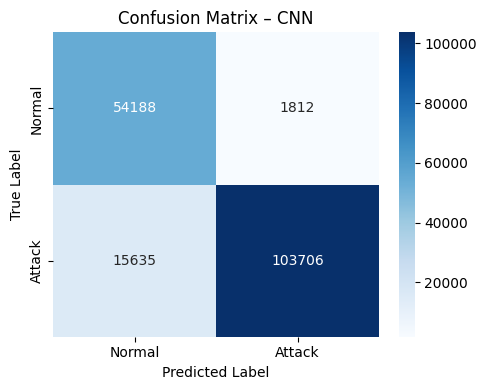

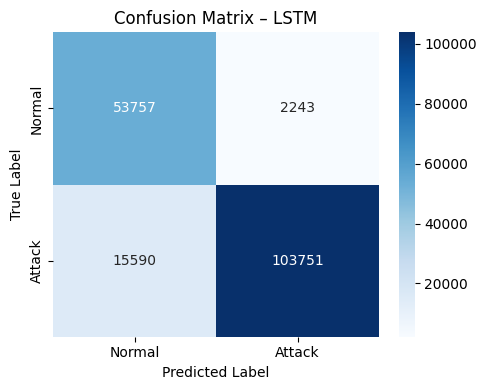

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score,
    precision_recall_curve
)


def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Normal', 'Attack'],
        yticklabels=['Normal', 'Attack']
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix – {model_name}")
    plt.tight_layout()
    plt.show()



plot_confusion_matrix(y_test, ann_pred, "ANN")
plot_confusion_matrix(y_test, cnn_pred, "CNN")
plot_confusion_matrix(y_test, lstm_pred, "LSTM")


def plot_roc_curve(y_true, y_prob, model_name):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve – {model_name}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"{model_name} ROC-AUC:", roc_auc)


In [7]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

def plot_pr_curve(y_true, y_prob, model_name):
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)

    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, linewidth=2, label=f"AP = {ap:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curve – {model_name}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


5480/5480 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step


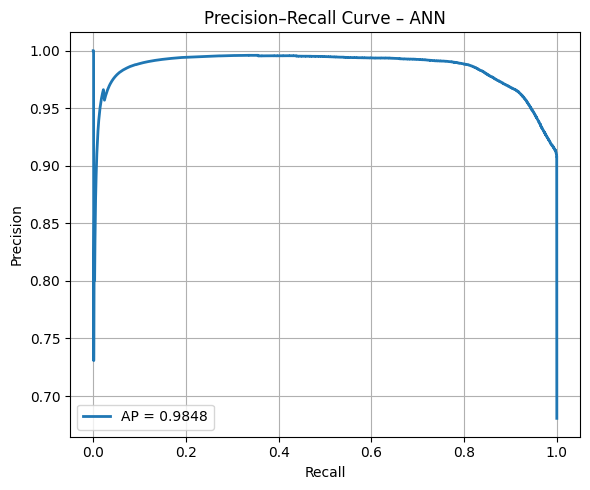

In [8]:
ann_prob = ann.predict(X_test)[:, 1]
plot_pr_curve(y_test, ann_prob, "ANN")


5480/5480 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step


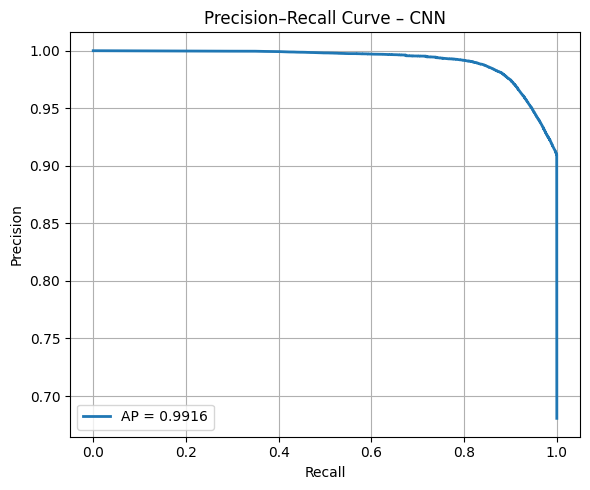

In [9]:
cnn_prob = cnn.predict(X_test_cnn)[:, 1]
plot_pr_curve(y_test, cnn_prob, "CNN")

5480/5480 ━━━━━━━━━━━━━━━━━━━━ 194s 35ms/step


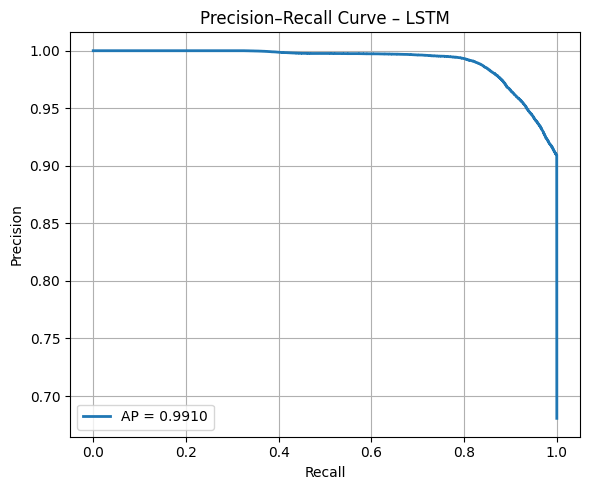

In [10]:
lstm_prob = lstm.predict(X_test_lstm)[:, 1]
plot_pr_curve(y_test, lstm_prob, "LSTM")

In [11]:
def plot_training_history(history, model_name):
    plt.figure(figsize=(12, 4))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(f'{model_name} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(['Train', 'Validation'])

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(f'{model_name} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(['Train', 'Validation'])

    plt.tight_layout()
    plt.show()


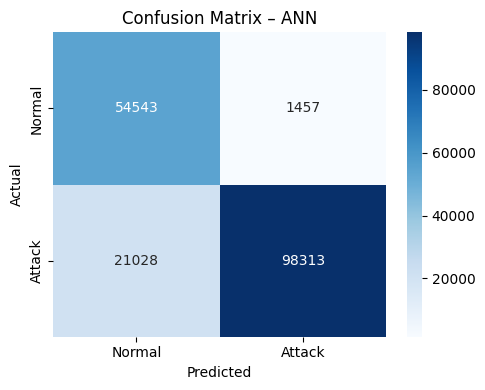

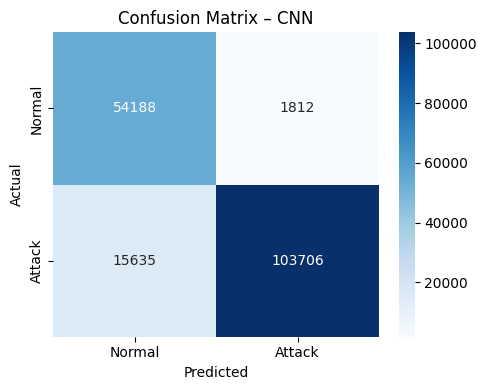

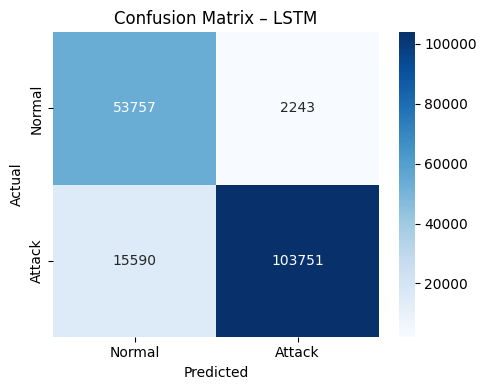

5480/5480 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step
5480/5480 ━━━━━━━━━━━━━━━━━━━━ 32s 6ms/step
5480/5480 ━━━━━━━━━━━━━━━━━━━━ 111s 20ms/step


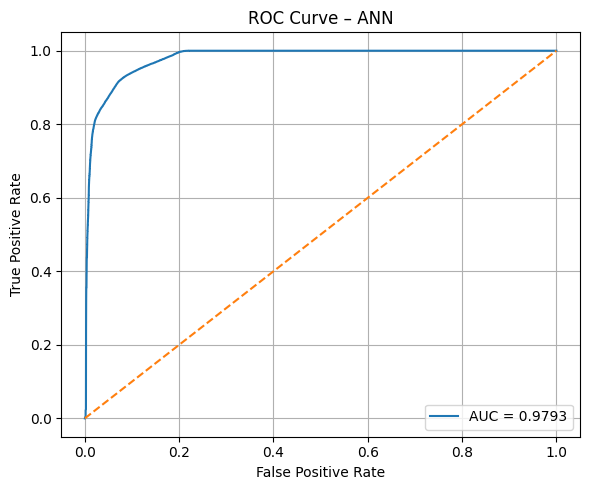

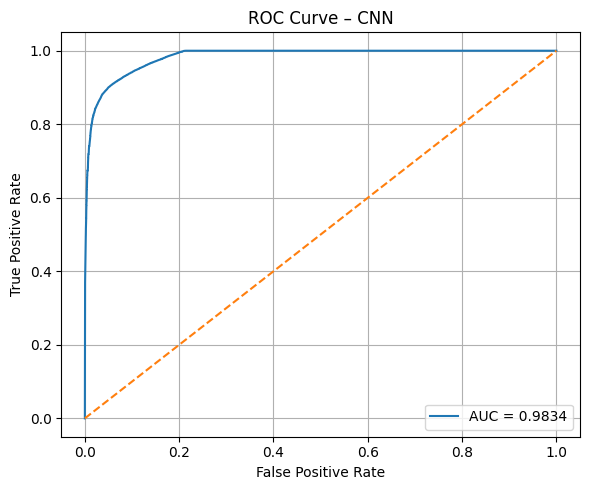

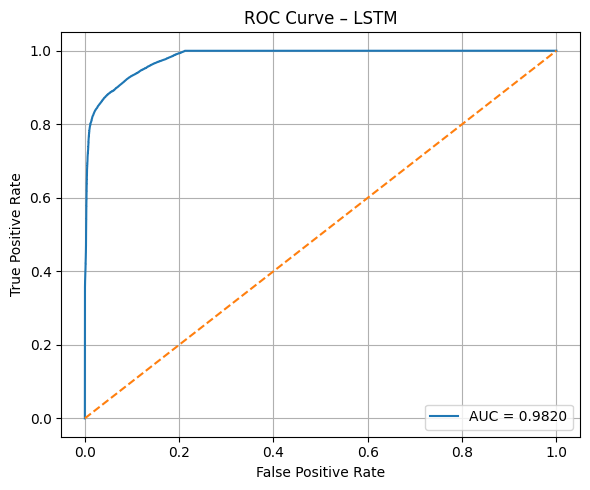

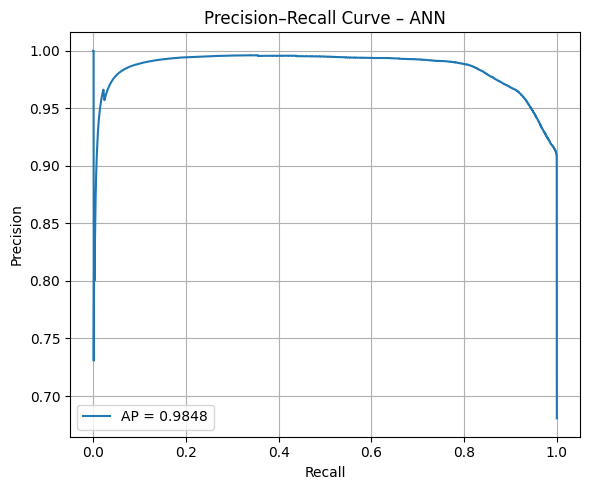

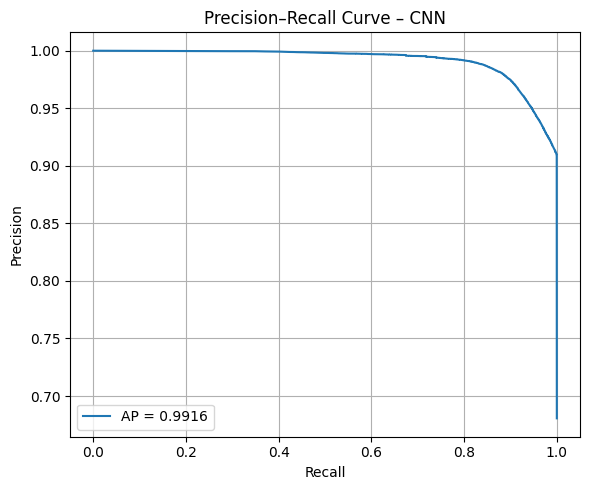

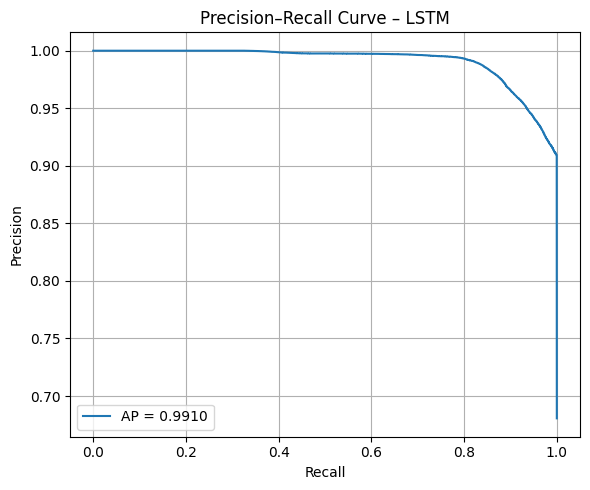

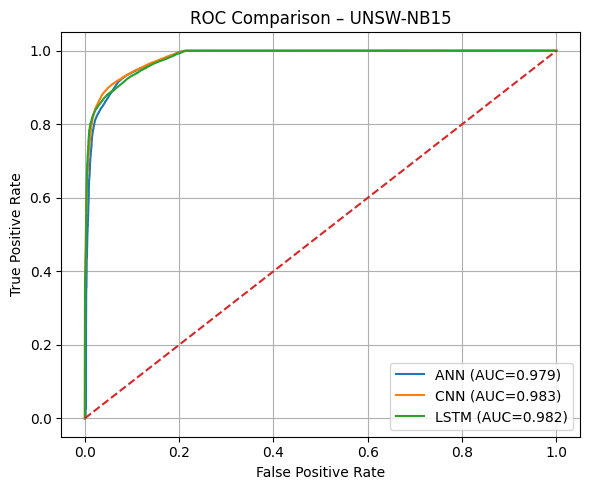

In [12]:
# ===================== IMPORTS =====================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

# ===================== CLASS NAMES =====================
class_names = ['Normal', 'Attack']

# ===================== CONFUSION MATRIX =====================
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix – {model_name}")
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(y_test, ann_pred, "ANN")
plot_confusion_matrix(y_test, cnn_pred, "CNN")
plot_confusion_matrix(y_test, lstm_pred, "LSTM")

# ===================== ROC CURVE =====================
def plot_roc(y_true, y_prob, model_name):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve – {model_name}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Probabilities (IMPORTANT)
ann_prob  = ann.predict(X_test)[:,1]
cnn_prob  = cnn.predict(X_test_cnn)[:,1]
lstm_prob = lstm.predict(X_test_lstm)[:,1]

plot_roc(y_test, ann_prob, "ANN")
plot_roc(y_test, cnn_prob, "CNN")
plot_roc(y_test, lstm_prob, "LSTM")

# ===================== PRECISION–RECALL CURVE =====================
def plot_pr(y_true, y_prob, model_name):
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)

    plt.figure(figsize=(6,5))
    plt.plot(recall, precision, label=f"AP = {ap:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curve – {model_name}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_pr(y_test, ann_prob, "ANN")
plot_pr(y_test, cnn_prob, "CNN")
plot_pr(y_test, lstm_prob, "LSTM")

# ===================== COMPARATIVE ROC (JOURNAL GOLD) =====================
plt.figure(figsize=(6,5))
for prob, name in [
    (ann_prob, "ANN"),
    (cnn_prob, "CNN"),
    (lstm_prob, "LSTM")
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison – UNSW-NB15")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [13]:
pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# ===================== FEATURE NAMES =====================
feature_names = train_df.drop('label', axis=1).columns

# ===================== SAMPLE DATA (FOR SPEED) =====================
X_shap = X_train[np.random.choice(X_train.shape[0], 350, replace=False)]
X_test_shap = X_test[:500]

# ===================== SHAP EXPLAINER (ANN) =====================
explainer_ann = shap.KernelExplainer(
    lambda x: ann.predict(x)[:,1],
    X_shap
)

shap_values_ann = explainer_ann.shap_values(X_test_shap)

# ===================== GLOBAL EXPLANATION =====================
shap.summary_plot(
    shap_values_ann,
    X_test_shap,
    feature_names=feature_names,
    show=True
)

# ===================== LOCAL EXPLANATION (Single Sample) =====================
shap.force_plot(
    explainer_ann.expected_value,
    shap_values_ann[0],
    X_test_shap[0],
    feature_names=feature_names,
    matplotlib=True
)


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


Using 350 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/500 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
23319/23319 ━━━━━━━━━━━━━━━━━━━━ 44s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
23319/23319 ━━━━━━━━━━━━━━━━━━━━ 43s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
23319/23319 ━━━━━━━━━━━━━━━━━━━━ 42s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
23319/23319 ━━━━━━━━━━━━━━━━━━━━ 42s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
23319/23319 ━━━━━━━━━━━━━━━━━━━━ 42s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
23319/23319 ━━━━━━━━━━━━━━━━━━━━ 43s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
23319/23319 ━━━━━━━━━━━━━━━━━━━━ 43s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
23319/23319 ━━━━━━━━━━━━━━━━━━━━ 42s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
23319/23319 ━━━━━━━━━━━━━━━━━━━━ 42s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
23319/23319 ━━━━━━━━━━━━━━━━━━━━ 42s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
23319/23319 ━━━━━━━━━━━━━━━━━━━━ 42s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
23319/23319 ━━━━━━━━━━━━━━━━━━━━ 43s 2

KeyboardInterrupt: 